
# **<font color='purple'> `Part 5: Variational Autoencoder for Synthetic Samples`</font>**
***
**Student**


|         Full name         |   Username  |         Email         |
|---------------------------|-------------|-----------------------|
| Emmanuel Nyandu Kagarabi  | emmanuelnk  | emmanuelnk@aims.ac.za |

<font color='teal'>`AI-Powered Classification and Early Detection of Dengue Lineages for a Timely Public Health Response`</font>

# `0. Imports`

In [ ]:
# Installations
!pip install Bio
!pip install imbalanced-learn
!pip install pandas biopython
!pip install scikit-learn
!pip install dask[dataframe]
# Clean installation outputs`
from IPython.display import clear_output
clear_output()

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input, Conv1D,Conv2D,MaxPooling1D,MaxPooling2D, Flatten,BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter
from Bio import SeqIO, Phylo
import re
import os
import zipfile
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score, confusion_matrix, roc_curve, auc, classification_report)
from xgboost import XGBClassifier
#from sklearn.utils.multiclass import unique_label
from scipy.stats import entropy
from datetime import datetime
from random import shuffle
import joblib
%matplotlib inline
import time
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Random Sampling
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from itertools import cycle
now = datetime.now()
now.strftime("%H:%M:%S")

2024-10-07 23:55:16.169372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-07 23:55:16.190991: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-07 23:55:16.197418: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-07 23:55:16.213021: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-07 23:55:17.326274: W tensorflow/compiler/tf2

'23:55:18'

# `1. Dataset`

In [ ]:
df = pd.read_csv('/content/FINAL_DATASET/MERGED/df_hierarchical.csv')
df.head()

,Sequence,Lineage,Hierarchy,Lineage_Splitted,Length,Serotype,Collection date,Submission date,Location
0,TAGTCTACGTGGACCGACAAGAACAGTTTCGAATCGGAAGCTTGCT...,1I_K.2,"['1', 'I', 'K', '2']",1_I_K_2,10652,DENV1,2022-05-24,2023-11-16,Asia / Indonesia / Bali
1,CGTGGACCGACAAAGACAGATTCTTTGAGGAAGCTAAGCTTAACGT...,2II_F.1.2,"['2', 'II', 'F', '1.2']",2_II_F_1.2,10490,DENV2,2024-03-22,2024-05-24,South America / Ecuador / Loja
2,CGACTCGGAAGCTTGCTTAACGTAGTGCTAACAGTTTTTATTAGAG...,3III_B.3,"['3', 'III', 'B', '3']",3_III_B_3,10461,DENV3,2023-06-08,2023-10-10,North America / USA / Florida
3,CACAGTTGGCGAAGAGATTCTCAAAAGGATTGCTGAACGGCCAGGG...,3III_C.2,"['3', 'III', 'C', '2']",3_III_C_2,10393,DENV3,2022-09-27,2023-05-20,North America / Mexico / Veracruz
4,TTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTTTATT...,1V_D.1,"['1', 'V', 'D', '1']",1_V_D_1,10087,DENV1,2020-12-18,2023-04-13,North America / USA / Florida


# `3. Variational Autoencoder`

`3.1. Helpers`

In [ ]:
def one_hot_encode(sequence, max_length):
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}
    encoded = [mapping.get(nucleotide, [0,0,0,0]) for nucleotide in sequence]
    padded = encoded + [[0,0,0,0]] * (max_length - len(encoded))
    return np.array(padded).flatten()

def reverse_one_hot_encode(one_hot_seq):
    mapping = {(1,0,0,0): 'A', (0,1,0,0): 'C', (0,0,1,0): 'G', (0,0,0,1): 'T'}
    sequence = ''
    for i in range(0, len(one_hot_seq), 4):
        nucleotide = tuple(np.round(one_hot_seq[i:i+4]).astype(int))  # Round values
        sequence += mapping.get(nucleotide, 'N')  # Use 'N' for unknown nucleotides
    return sequence.rstrip('N')

In [ ]:
# Try
S1 = "ACAAGAACAGTTTCGAATCGGA"
max_length=len(S1)
S2 = "ACAAGAACAGTTT"

In [ ]:
# One-hot-encoding:
S1_encoded = one_hot_encode(S1, max_length)
print(f"One-hot-encoded sequence of {S1} =\n {S1_encoded}")
#print a reverse_one_hot_encod
print(f"Reverse one-hot-encoded sequence of {S1_encoded} =\n {reverse_one_hot_encode(S1_encoded)}")
S2_encoded = one_hot_encode(S2, max_length)
print(f"One-hot-encoded sequence of {S2}=\n   {S2_encoded}")

One-hot-encoded sequence of ACAAGAACAGTTTCGAATCGGA =
 [1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0
 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1
 0 0 0 0 1 0 0 0 1 0 1 0 0 0]
Reverse one-hot-encoded sequence of [1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0
 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1
 0 0 0 0 1 0 0 0 1 0 1 0 0 0] =
 ACAAGAACAGTTTCGAATCGGA
One-hot-encoded sequence of ACAAGAACAGTTT=
   [1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0
 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


`3.2. Model Visualisation in Netron`

In [ ]:
# Ensure the model doesn't use mixed precision
tf.keras.mixed_precision.set_global_policy('float32')

# Function to build the VAE as a single model (encoder, latent space, decoder)
def build_complete_vae(input_dim, latent_dim):
    # Encoder
    inputs = layers.Input(shape=(input_dim,), dtype='float32', name='encoder_input')
    x = layers.Dense(512, activation="relu", dtype='float32')(inputs)
    x = layers.Dense(256, activation="relu", dtype='float32')(x)
    z_mean = layers.Dense(latent_dim, dtype='float32', name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, dtype='float32', name='z_log_var')(x)

    # Sampling layer (Latent Space)
    def sampling(args):
        z_mean, z_log_var = args
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim), dtype=tf.float32)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(sampling, output_shape=(latent_dim,), dtype='float32', name='z')([z_mean, z_log_var])

    # Decoder
    x = layers.Dense(256, activation="relu", dtype='float32', name='decoder_dense_1')(z)
    x = layers.Dense(512, activation="relu", dtype='float32', name='decoder_dense_2')(x)
    outputs = layers.Dense(input_dim, activation="sigmoid", dtype='float32', name='decoder_output')(x)

    # Complete VAE model (encoder + latent space + decoder)
    vae = Model(inputs, outputs, name='vae_model')

    vae.compile(optimizer='adam')

    return vae

# Build the complete VAE model with specific input and latent dimensions
input_dim = 10821 * 4  # Example for the one-hot encoded input sequence
latent_dim = 64  # Example latent space dimension
vae_model = build_complete_vae(input_dim, latent_dim)

# Save the model for Netron visualization
vae_model.save('/content/FINAL_DATASET/FINAL_VAE/vae_model_for_netron.keras')

print("VAE model saved successfully.")

I0000 00:00:1728345362.192009   85293 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1728345362.192448   85293 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1728345362.260191   85293 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1728345362.260551   85293 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

VAE model saved successfully.


# `4. SYNTHETIC SAMPLES`

# `4.1. Using VAE without sampling`

In [ ]:
# One-hot encoding
def one_hot_encode(sequence):
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}
    return [mapping.get(nucleotide, [0,0,0,0]) for nucleotide in sequence]

x = []
y = []
lineages = df['Lineage'].unique()
lineage_to_index = {lineage: index for index, lineage in enumerate(lineages)}

max_length = df['Length'].max()

for _, row in df.iterrows():
    sequence = row['Sequence']
    lineage = row['Lineage']
    x.append(one_hot_encode(sequence))
    y.append(lineage_to_index[lineage])

# Pad sequences
x = pad_sequences(x, maxlen=max_length, padding='post')

x_train, x_test, y_train, y_test = train_test_split(x, y,stratify=y, test_size=0.2, random_state=42)

x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Convert to categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
# Ensure the model doesn't use mixed precision
tf.keras.mixed_precision.set_global_policy('float32')

# Custom VAE model with its own training step
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction), axis=-1
                )
            )
            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            # Total loss
            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

In [ ]:
def build_vae(input_dim, latent_dim):
    # Encoder definition
    inputs = layers.Input(shape=(input_dim,), dtype='float32')
    x = layers.Dense(512, activation="relu", dtype='float32')(inputs)
    x = layers.Dense(256, activation="relu", dtype='float32')(x)
    z_mean = layers.Dense(latent_dim, dtype='float32')(x)
    z_log_var = layers.Dense(latent_dim, dtype='float32')(x)

    # Sampling layer
    def sampling(args):
        z_mean, z_log_var = args
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim), dtype=tf.float32)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(sampling, output_shape=(latent_dim,), dtype='float32')([z_mean, z_log_var])

    # Decoder definition
    decoder_inputs = layers.Input(shape=(latent_dim,), dtype='float32')
    x = layers.Dense(256, activation="relu", dtype='float32')(decoder_inputs)
    x = layers.Dense(512, activation="relu", dtype='float32')(x)
    outputs = layers.Dense(input_dim, activation="sigmoid", dtype='float32')(x)

    encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")
    decoder = Model(decoder_inputs, outputs, name="decoder")

    # VAE model
    vae = VAE(encoder, decoder)
    vae.compile(optimizer='adam')

    return vae, encoder, decoder


def one_hot_encode(sequence, max_length):
    mapping = {'A': [1, 0, 0, 0], 'C': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'T': [0, 0, 0, 1]}
    encoded = [mapping.get(nucleotide, [0, 0, 0, 0]) for nucleotide in sequence]
    padded = encoded + [[0, 0, 0, 0]] * (max_length - len(encoded))
    return np.array(padded).flatten()


def reverse_one_hot_encode(one_hot_seq):
    mapping = {(1, 0, 0, 0): 'A', (0, 1, 0, 0): 'C', (0, 0, 1, 0): 'G', (0, 0, 0, 1): 'T'}
    sequence = ''
    for i in range(0, len(one_hot_seq), 4):
        nucleotide = tuple(np.round(one_hot_seq[i:i + 4]).astype(int))  # Round values
        sequence += mapping.get(nucleotide, 'N')  # Use 'N' for unknown nucleotides
    return sequence.rstrip('N')

In [ ]:
def plot_vae_history(history, fileNamePLT,figsize=(12, 4)):

    # Create a figure with three subplots side by side
    fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=figsize)

    # Plot the total loss on the first subplot
    ax1.plot(history['loss'],color='blue', label='Total Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper right')
    ax1.grid(linestyle='--')

    # Plot the reconstruction loss on the second subplot
    ax2.plot(history['reconstruction_loss'],color='teal', label='Reconstruction Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')
    ax2.grid(linestyle='--')

    # Plot the KL loss on the third subplot
    ax3.plot(history['kl_loss'],color='magenta', label='KL Divergence Loss')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.legend(loc='upper right')
    ax3.grid(linestyle='--')

    # Adjust layout to prevent overlap
    plt.tight_layout()
    # Save the figure
    fileNamePLT = fileNamePLT+ "VAE_LOSSES.pdf"
    # Save at a given path
    fileNamePLT = "/content/FIGURES"+fileNamePLT
    plt.savefig(fileNamePLT)

    # Show the plots
    plt.show()


# Function to calculate entropy for prediction
def cal_entropy(probabilities):
    return entropy(probabilities, axis=-1, base=2)


# Predict if sequence is a new variant based on entropy
def dengue_variant_prediction(model, seq, threshold=0.15):
    preds = model.predict(np.expand_dims(seq, axis=0))
    score = cal_entropy(preds[0])

    if score > threshold:
        return 'New variant'
    else:
        variant = np.argmax(preds[0])
        return f'Variant {variant}'


# Save generated sequences to a FASTA file
def save_to_fasta(sequences, file_path):
    with open(file_path, 'w') as f:
        for i, seq in enumerate(sequences):
            f.write(f">New_Variant_{i + 1}\n")
            f.write(f"{seq}\n")

In [ ]:
  max_length = df['Length'].max()
  input_dim = max_length * 4  # One-hot encoded sequences will have this dimension
  latent_dim = 64

In [ ]:
# Prepare training data
x_train = np.array([one_hot_encode(seq, max_length) for seq in df['Sequence']], dtype=np.float32)

In [ ]:
# Train the model
vae, encoder, decoder = build_vae(input_dim, latent_dim)
history = vae.fit(x_train, epochs=100, batch_size=32)

Epoch 1/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - kl_loss: 26.6981 - loss: 41.6873 - reconstruction_loss: 14.9892
Epoch 2/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - kl_loss: 0.8198 - loss: 12.6499 - reconstruction_loss: 11.8300
Epoch 3/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - kl_loss: 0.6552 - loss: 11.6416 - reconstruction_loss: 10.9864
Epoch 4/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - kl_loss: 0.6652 - loss: 10.6925 - reconstruction_loss: 10.0273
Epoch 5/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - kl_loss: 0.7128 - loss: 10.0536 - reconstruction_loss: 9.3409
Epoch 6/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - kl_loss: 0.6851 - loss: 9.5776 - reconstruction_loss: 8.8925
Epoch 7/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - kl_loss: 0.6738 - loss: 9.1834 - reconstruction_loss: 8.5096
Epoch 8/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - kl_loss: 0.6640 - loss: 8.8000 - reconstruction_loss: 8.1360
Epoch 9/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step 

# `4.2. Using VAE with Sampling(SMOTE)`

**A. Model Architecture**

In [ ]:
# @title
# Ensure the model doesn't use mixed precision
tf.keras.mixed_precision.set_global_policy('float32')

# Custom VAE model with its own training step
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction), axis=-1
                )
            )
            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            # Total loss
            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

In [ ]:
# Function to build the VAE
def build_vae(input_dim, latent_dim):
    # Encoder definition
    inputs = layers.Input(shape=(input_dim,), dtype='float32')
    x = layers.Dense(512, activation="relu", dtype='float32')(inputs)
    x = layers.Dense(256, activation="relu", dtype='float32')(x)
    z_mean = layers.Dense(latent_dim, dtype='float32')(x)
    z_log_var = layers.Dense(latent_dim, dtype='float32')(x)

    # Sampling layer (Latent Space)
    def sampling(args):
        z_mean, z_log_var = args
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim), dtype=tf.float32)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(sampling, output_shape=(latent_dim,), dtype='float32')([z_mean, z_log_var])

    # Decoder definition
    decoder_inputs = layers.Input(shape=(latent_dim,), dtype='float32')
    x = layers.Dense(256, activation="relu", dtype='float32')(decoder_inputs)
    x = layers.Dense(512, activation="relu", dtype='float32')(x)
    outputs = layers.Dense(input_dim, activation="sigmoid", dtype='float32')(x)

    # Define models
    encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")
    decoder = Model(decoder_inputs, outputs, name="decoder")

    vae = VAE(encoder, decoder)
    vae.compile(optimizer='adam')

    return vae, encoder, decoder

In [ ]:
# One-hot encoding function
def one_hot_encode(sequence, max_length):
    mapping = {'A': [1, 0, 0, 0], 'C': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'T': [0, 0, 0, 1]}
    encoded = [mapping.get(nucleotide, [0, 0, 0, 0]) for nucleotide in sequence]
    padded = encoded + [[0, 0, 0, 0]] * (max_length - len(encoded))
    return np.array(padded).flatten()


# Reverse one-hot encoding function
def reverse_one_hot_encode(one_hot_seq):
    mapping = {(1, 0, 0, 0): 'A', (0, 1, 0, 0): 'C', (0, 0, 1, 0): 'G', (0, 0, 0, 1): 'T'}
    sequence = ''
    for i in range(0, len(one_hot_seq), 4):
        nucleotide = tuple(np.round(one_hot_seq[i:i + 4]).astype(int))  # Round values
        sequence += mapping.get(nucleotide, 'N')  # Use 'N' for unknown nucleotides
    return sequence.rstrip('N')


def plot_vae_history(history, fileNamePLT,figsize=(12, 4)):

    epochs = range(1, len(history['loss']) + 1)

    # Create a figure with three subplots side by side
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle('Variational Autoencoder Loss over Epochs',fontweight='bold',fontsize=12)

    # Plot the KL loss on the first subplot
    ax1.plot(epochs,history['kl_loss'],color='magenta', label='KL Divergence Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper right')
    ax1.grid(linestyle='--')

    # Plot the reconstruction loss on the second subplot
    ax2.plot(epochs,history['reconstruction_loss'], color='teal', label='Reconstruction Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')
    ax2.grid(linestyle='--')

    # Plot the total loss on the first subplot
    ax3.plot(epochs,history['loss'],color='blue',linewidth=2,alpha=1, label='Total Loss')#
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.legend(loc='upper right')
    ax3.grid(linestyle='--')

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Save the figure
    fileNamePLT = fileNamePLT+ "VAE_SMOTE_LOSSES.pdf"
    # Save at a given path
    fileNamePLT = "/content/FIGURES/"+fileNamePLT
    plt.savefig(fileNamePLT)

    # Show the plots
    plt.show()

# Save generated sequences to a FASTA file
def save_to_fasta(sequences, file_path):
    with open(file_path, 'w') as f:
        for i, seq in enumerate(sequences):
            f.write(f">VAE_SAMPLE_{i + 1}\n")
            f.write(f"{seq}\n")

**B. HYPERPARAMETERS**

In [ ]:
max_length = df['Length'].max()
input_dim = max_length * 4  #
latent_dim = 64

**C. DATASET**

In [ ]:
x = []
y = []

lineages = df['Lineage'].unique()
lineage_to_index = {lineage: index for index, lineage in enumerate(lineages)}

# Convert sequences to one-hot encoded format and prepare labels
for _, row in df.iterrows():
    sequence = row['Sequence']
    lineage = row['Lineage']

    # Convert the sequence to one-hot encoding
    one_hot_encoded_seq = one_hot_encode(sequence, max_length)
    x.append(one_hot_encoded_seq)
    y.append(lineage_to_index[lineage])

# Print original class distribution
print("Original class distribution:")
print(Counter(y))

# Convert lists to arrays
x = np.array(x, dtype=np.float32)
y = np.array(y)

# Split the data (use stratify=y to maintain the distribution of classes)
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.02, random_state=42)

# Apply SMOTE only on the training data
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# Print resampled class distribution
print("\nResampled class distribution:")
print(Counter(y_train_resampled))

# Convert labels back to categorical (one-hot encoding) after resampling
y_train_resampled = to_categorical(y_train_resampled, num_classes=len(lineages))
y_test = to_categorical(y_test, num_classes=len(lineages))
# Number of samples in the dataset
print(f"The VAE is gonna be trained with shapes {x_train_resampled.shape}.")

Original class distribution:
Counter({4: 678, 2: 520, 9: 420, 17: 314, 1: 291, 10: 202, 14: 92, 11: 89, 33: 80, 8: 72, 25: 59, 26: 51, 12: 47, 6: 45, 23: 43, 24: 38, 7: 36, 16: 36, 30: 32, 31: 32, 0: 27, 28: 27, 29: 27, 13: 26, 21: 26, 18: 25, 35: 23, 15: 19, 19: 18, 27: 18, 5: 17, 36: 16, 3: 14, 22: 14, 32: 14, 34: 14, 37: 14, 20: 11})

Resampled class distribution:
Counter({36: 664, 9: 664, 17: 664, 33: 664, 14: 664, 10: 664, 26: 664, 23: 664, 20: 664, 7: 664, 8: 664, 34: 664, 25: 664, 4: 664, 2: 664, 13: 664, 1: 664, 21: 664, 37: 664, 22: 664, 24: 664, 11: 664, 27: 664, 6: 664, 12: 664, 29: 664, 3: 664, 5: 664, 16: 664, 28: 664, 31: 664, 18: 664, 0: 664, 15: 664, 19: 664, 30: 664, 35: 664, 32: 664})
The VAE is gonna be trained with shapes (25232, 43284).


In [ ]:
# Define VAE model
vae, encoder, decoder = build_vae(input_dim, latent_dim)

In [ ]:
# Train the VAE model
history_vae = vae.fit(x_train_resampled, epochs=250, batch_size=64)

Epoch 1/250


I0000 00:00:1728094043.133803   26031 service.cc:146] XLA service 0x7f7ea800c930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728094043.133872   26031 service.cc:154]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1728094043.133877   26031 service.cc:154]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2024-10-05 02:07:23.184663: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-05 02:07:23.468243: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906


 13/395 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - kl_loss: 21.1398 - loss: 57.4700 - reconstruction_loss: 36.3302

I0000 00:00:1728094045.426827   26031 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


395/395 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - kl_loss: 1.8783 - loss: 25.2143 - reconstruction_loss: 23.3360
Epoch 2/250
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 1.1400 - loss: 16.7964 - reconstruction_loss: 15.6564
Epoch 3/250
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 1.1541 - loss: 13.9826 - reconstruction_loss: 12.8285
Epoch 4/250
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 1.1469 - loss: 12.3677 - reconstruction_loss: 11.2208
Epoch 5/250
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 1.1420 - loss: 11.4051 - reconstruction_loss: 10.2631
Epoch 6/250
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 1.1236 - loss: 10.7309 - reconstruction_loss: 9.6073
Epoch 7/250
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - kl_loss: 1.0947 - loss: 10.2120 - reconstruction_loss: 9.1172
Epoch 8/250
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 1.0886 - loss: 9.9400 - reconstruction_loss: 8.8514
Epoch 9/250
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - kl_loss

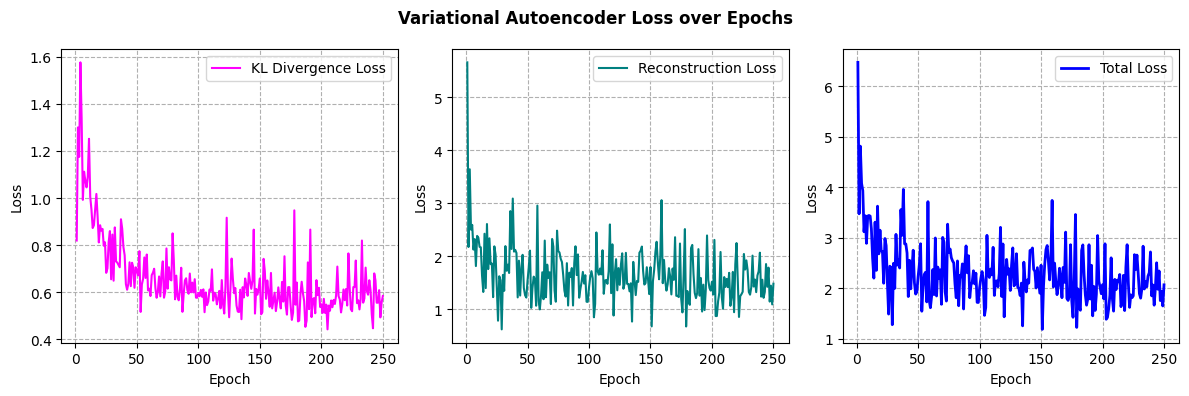

In [ ]:
# Plot the loss history
plot_vae_history(history_vae.history,fileNamePLT='SMOTE_DENGUE')

In [ ]:
# Generate new sequences from the VAE
n_new_variants = 200
z_sample = np.random.normal(size=(n_new_variants, latent_dim)).astype(np.float32)
x_decoded = decoder.predict(z_sample)
# Reshape the decoded sequences back to the original shape
x_decoded = x_decoded.reshape((n_new_variants, max_length, 4))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [ ]:
# Convert generated sequences back to nucleotide sequences
new_sequences = []
for decoded_seq in x_decoded:
    nucleotide_seq = reverse_one_hot_encode(decoded_seq.flatten())
    new_sequences.append(nucleotide_seq)

# Save generated sequences to a .fasta file
fasta_path = "/content/FINAL_DATASET/FINAL_VAE/200smote_generated_sequences.fasta"
save_to_fasta(new_sequences, fasta_path)
print(f"Generated {len(new_sequences)} new sequences saved to {fasta_path}")

Generated 200 new sequences saved to /content/FINAL_DATASET/FINAL_VAE/200smote_generated_sequences.fasta


# `5. Read and Clean the generated sequences`

In [ ]:
# Convert the generated dataset to a dataframe
def fasta_to_dataframe(fasta_file):
    records = []
    for record in SeqIO.parse(fasta_file, 'fasta'):
        records.append({
            'ID': record.description,
            'Sequence': str(record.seq)
        })
    df = pd.DataFrame(records)
    return df
# Read in the generated dataframe
generated_fasta_path = "/content/FINAL_DATASET/FINAL_VAE/200smote_generated_sequences.fasta"#/content/100b_cleaned_generated_sequences.fasta"
generated_df = fasta_to_dataframe(generated_fasta_path)
generated_df.head()

,ID,Sequence
0,VAE_SAMPLE_1,NGNTNNTNNTNNANGNANNGNCANNAACANANNTGCNTCGAANANT...
1,VAE_SAMPLE_2,CANNNTNGGCNNAGAGANTNNCAAAANGANNGCNGAACNGNNAGGN...
2,VAE_SAMPLE_3,ANTNAGANNCTTNCNNAANACANNNNTANCNNNTCNTNNAGANAGN...
3,VAE_SAMPLE_4,TTCTTTGAGGGAGCTAAGCTCAACGTAGTTCTAACAGTTTTTTANT...
4,VAE_SAMPLE_5,AATCGGAAANTTTCNAAACNCAGNNNTNCNNAANGNNNTNCNNAGA...


In [ ]:
# Cleaning the dataset
def clean_generated_data(df):
    # Remove ambiguous nucleotides
    valid_letters = ['A', 'C', 'G', 'T']
    df['Sequence'] = df['Sequence'].apply(lambda seq: ''.join([n for n in seq if n in valid_letters]))
    # Add a column which computes the sequence length
    df['Length'] = df['Sequence'].apply(lambda seq: len(seq))
    return df
# Clean our generated dataset
generated_df = clean_generated_data(generated_df)
generated_df

,ID,Sequence,Length
0,VAE_SAMPLE_1,GTTTAGAGCAAACAATGCTCGAAATTAGTTTCTAAGTGTAGAAGAC...,5548
1,VAE_SAMPLE_2,CATGGCAGAGATCAAAAGAGCGAACGAGGACCAAGAAGTTATGGTT...,6373
2,VAE_SAMPLE_3,ATAGACTTCAAACATACTCTAGAAGAATTTGAAAATGAACAACAAA...,4492
3,VAE_SAMPLE_4,TTCTTTGAGGGAGCTAAGCTCAACGTAGTTCTAACAGTTTTTTATT...,4363
4,VAE_SAMPLE_5,AATCGGAAATTTCAAACCAGTCAAGTCAGAGTTTTTCGGGAAAGCT...,5452
...,...,...,...
195,VAE_SAMPLE_196,TGTTTCTCGTGGACCGACAAAGAAGATTCTTTGAGGAGCTTCAAAT...,7021
196,VAE_SAMPLE_197,ATAGTGACAGGAAGAGTTATGATAACAAAAAGGGAAGTAGAAGAAA...,4352
197,VAE_SAMPLE_198,GTATACTCCCGAAGGCTACAATCGGAATTTTAAGCTTAATTGTTTA...,7324
198,VAE_SAMPLE_199,TTTTAGATAGCTAAGCCCAGTTCTTATGTTTATAGTAGTTTCTGAT...,6297
